# Data Exploration

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import glob


sys.path.append(os.path.abspath("../scripts"))

from evaluate import evaluate_model

# Import modules
import config
import feature_engineering
import data_pipeline
import model_training
import plots
from evaluate import evaluate_model

# Function to reload all custom modules (use when needed)
def reload_modules():
    """Reload all custom modules for development"""
    importlib.reload(config)
    importlib.reload(feature_engineering)
    importlib.reload(data_pipeline)
    importlib.reload(model_training)
    importlib.reload(plots)
    print("All modules reloaded!")

In [9]:
df = data_pipeline.load_data("03-06-24", "A1.csv")
df.columns.values

array(['mode', 'ox/red', 'error', 'control changes', 'Ns changes',
       'counter inc.', 'Ns', 'I Range', 'time/s', 'control/V/mA',
       'Ecell/V', 'I/mA', 'dq/mA.h', '(Q-Qo)/mA.h', '|Energy|/W.h',
       'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'Q charge/discharge/mA.h',
       'half cycle', 'Energy charge/W.h', 'Energy discharge/W.h',
       'Capacitance charge/µF', 'Capacitance discharge/µF', 'step time/s',
       'z cycle', 'Re(Z)/Ohm', 'Im(Z)/Ohm', 'Re(Y)/Ohm-1', 'Im(Y)/Ohm-1',
       '|Y|/Ohm-1', 'Phase(Y)/deg', 'x', 'Q discharge/mA.h',
       'Q charge/mA.h', 'Capacity/mA.h', 'Efficiency/%', 'control/V',
       'control/mA', 'cycle number', 'P/W', 'R/Ohm'], dtype=object)

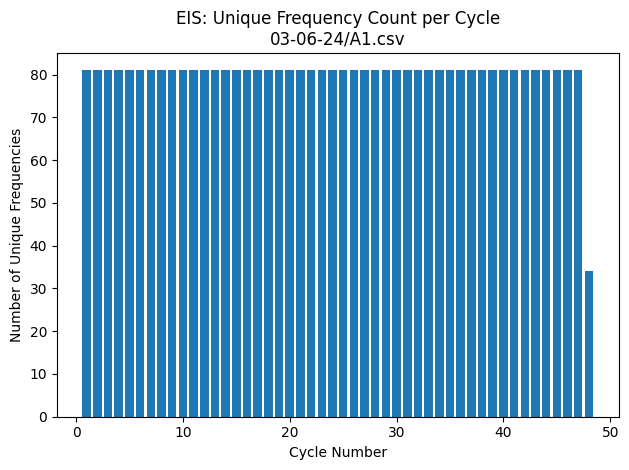

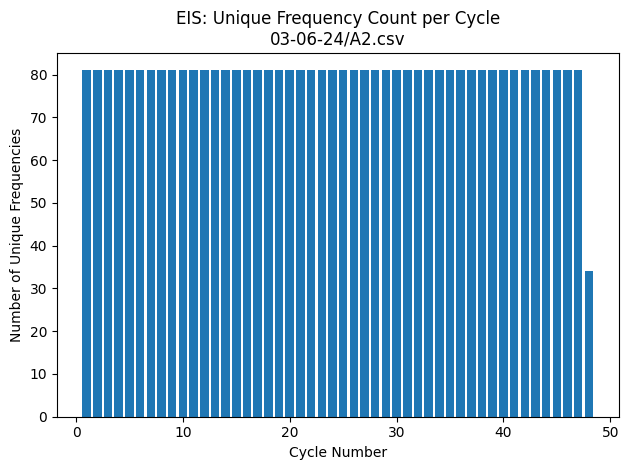

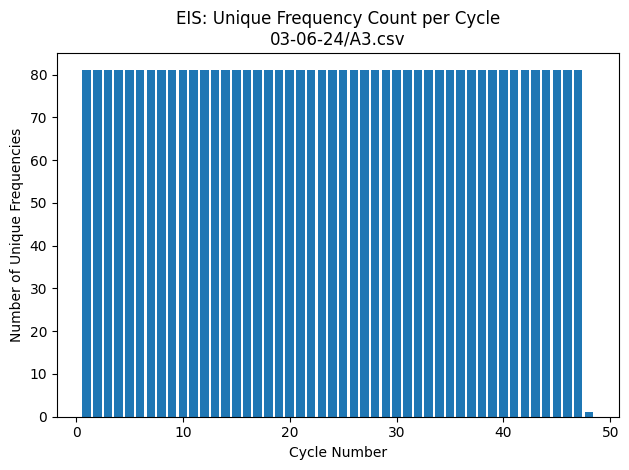

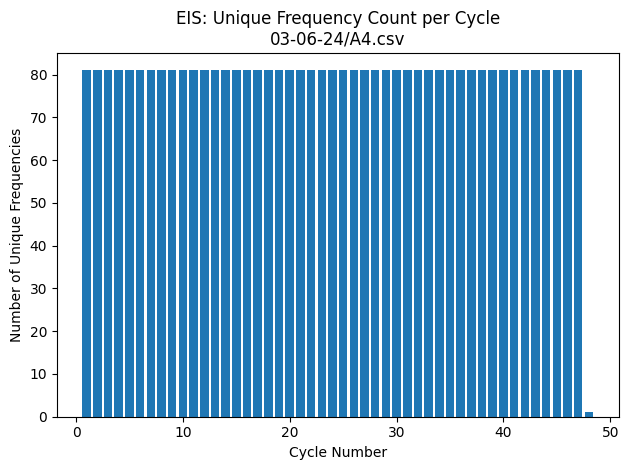

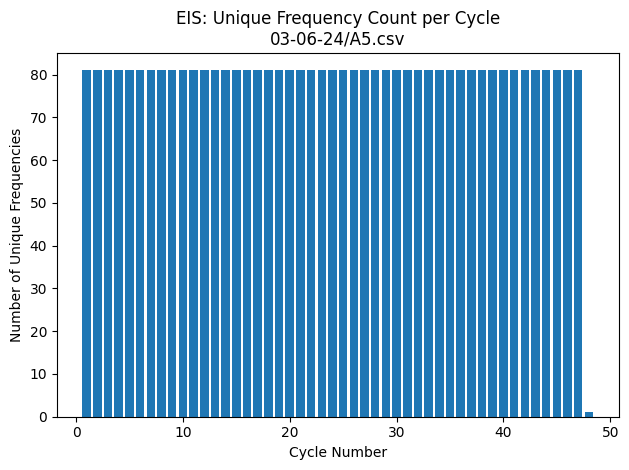

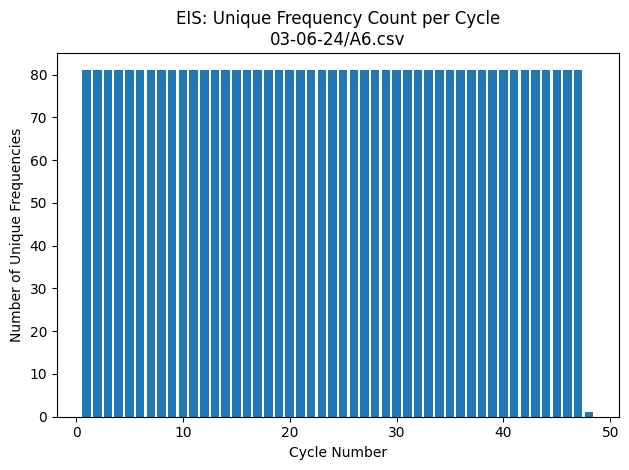

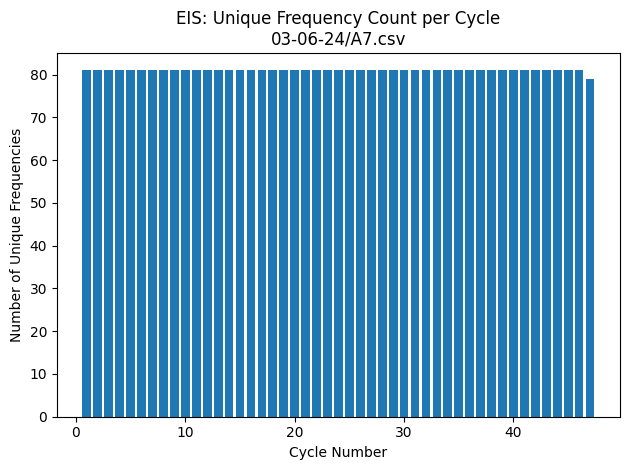

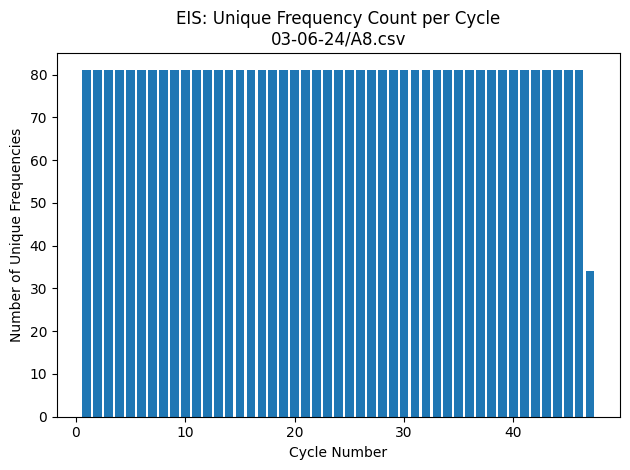

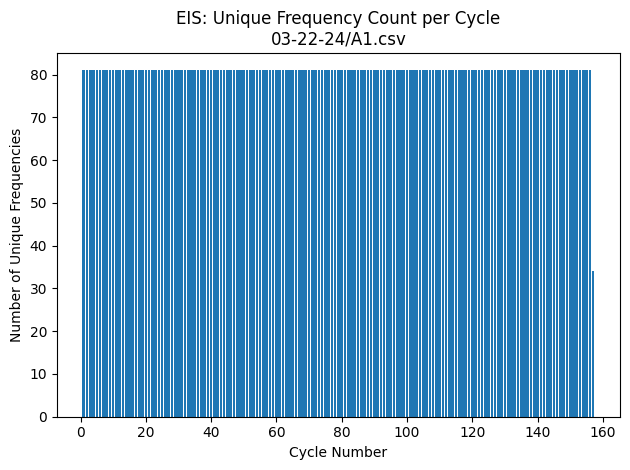

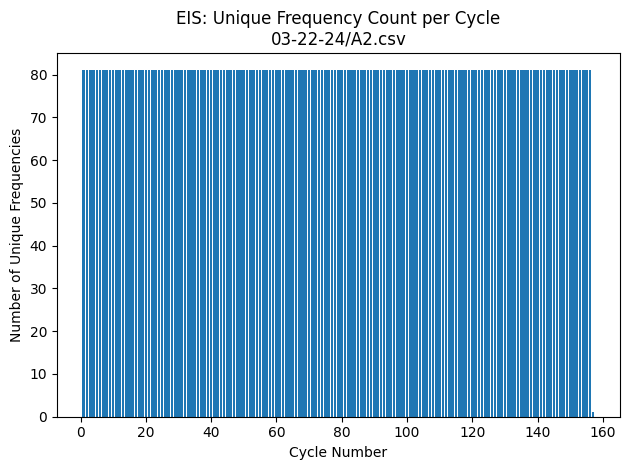

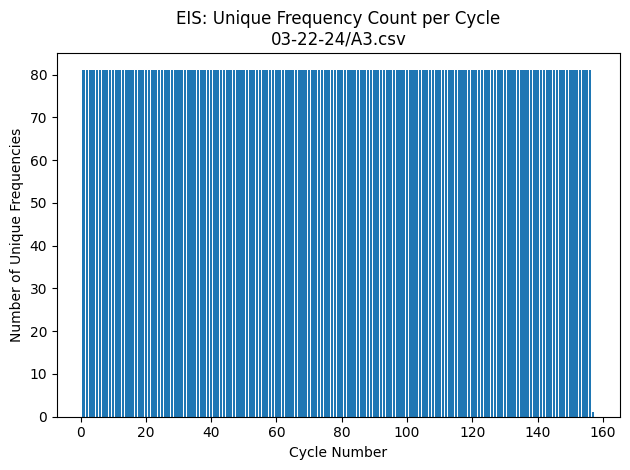

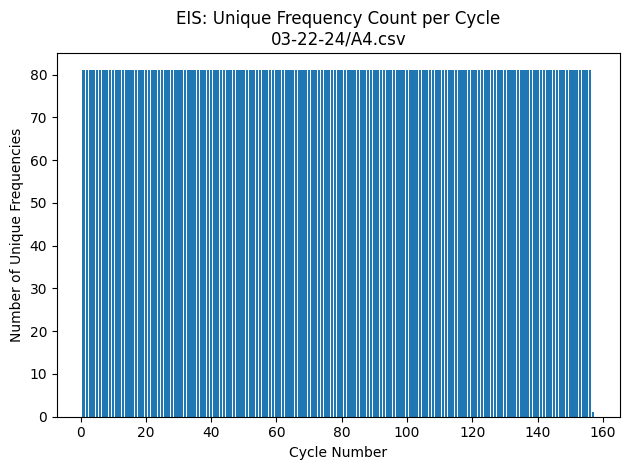

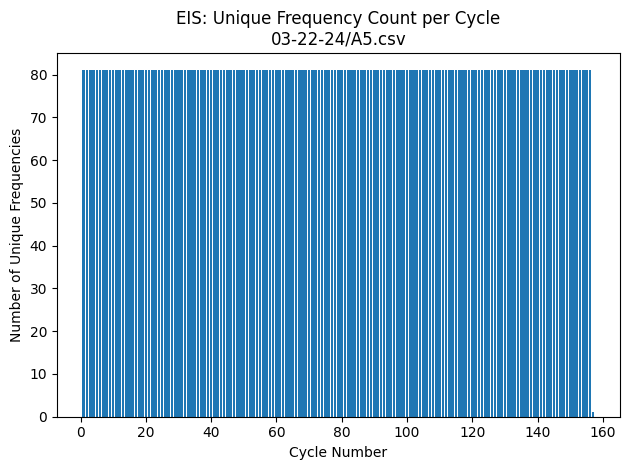

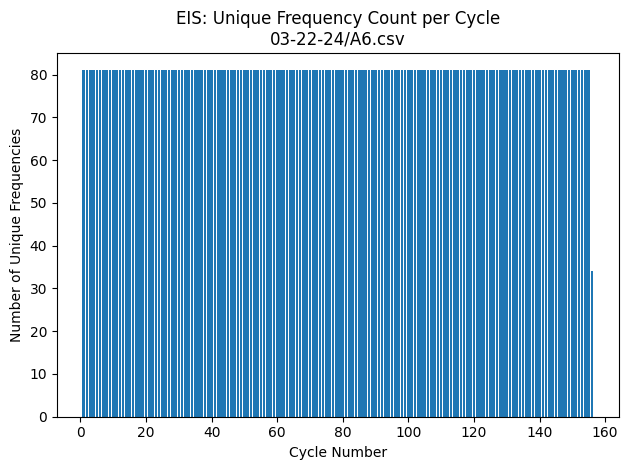

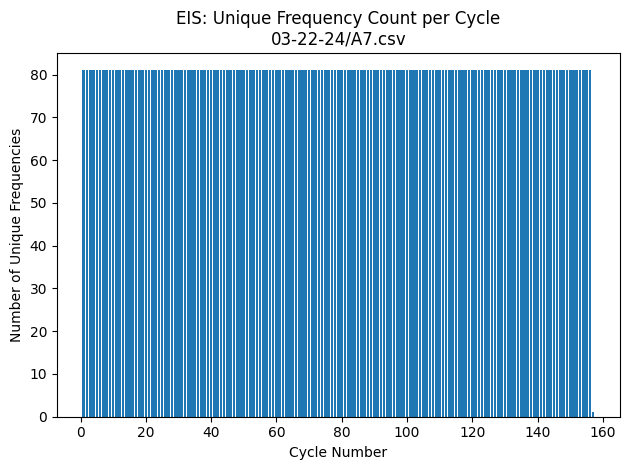

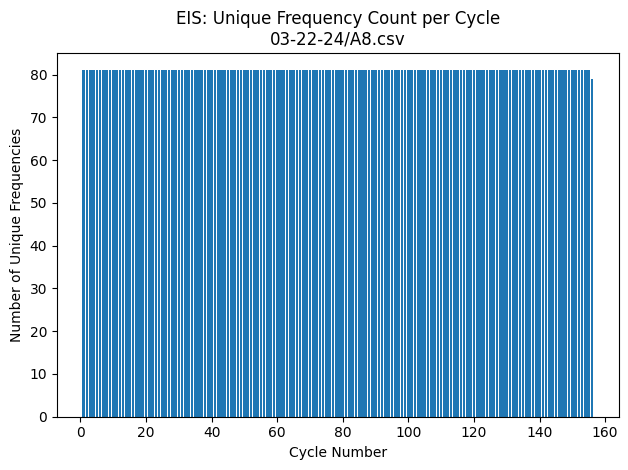

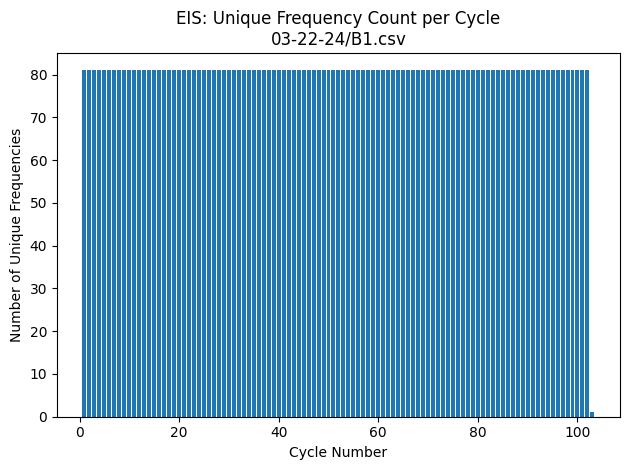

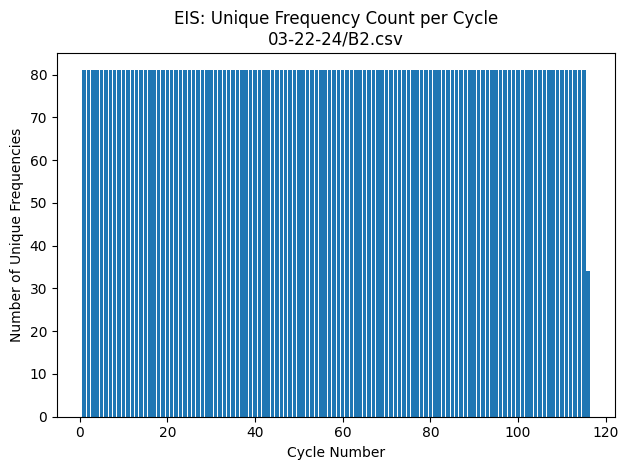

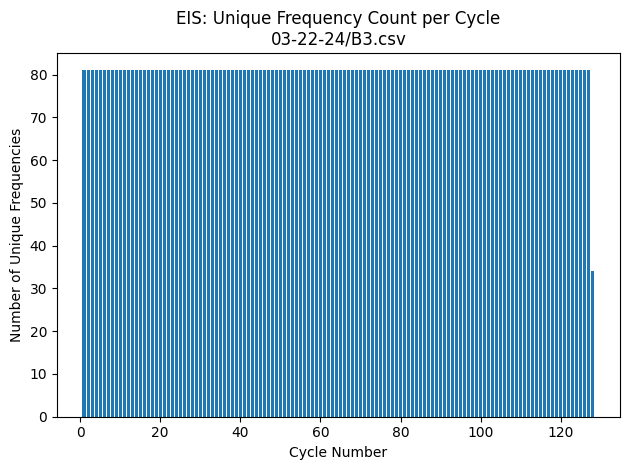

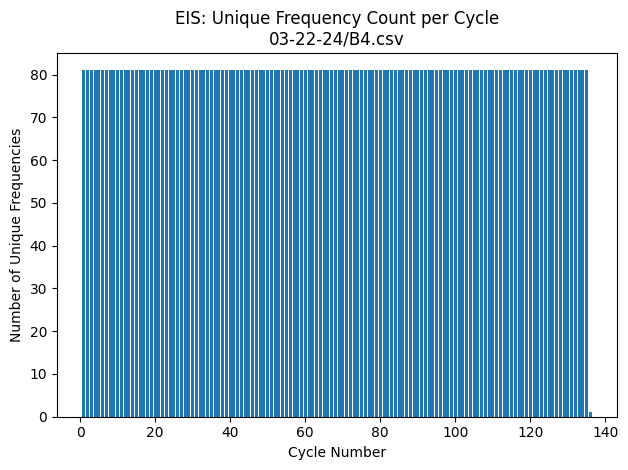

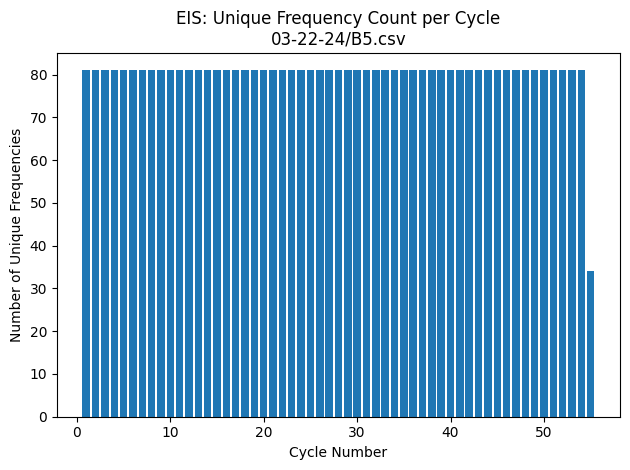

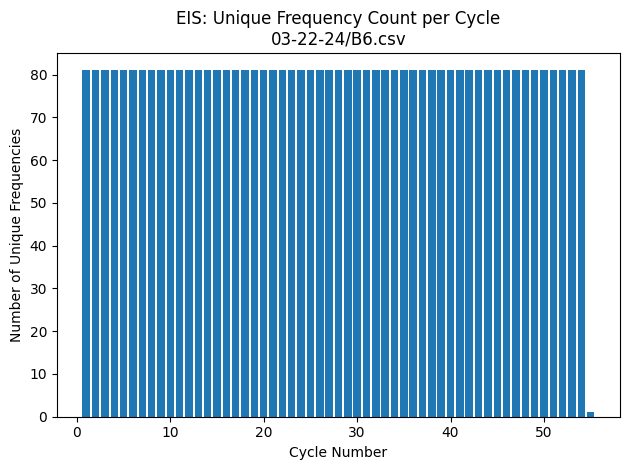

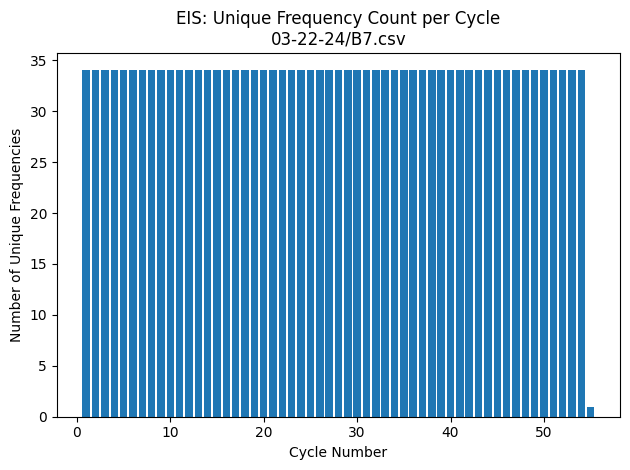

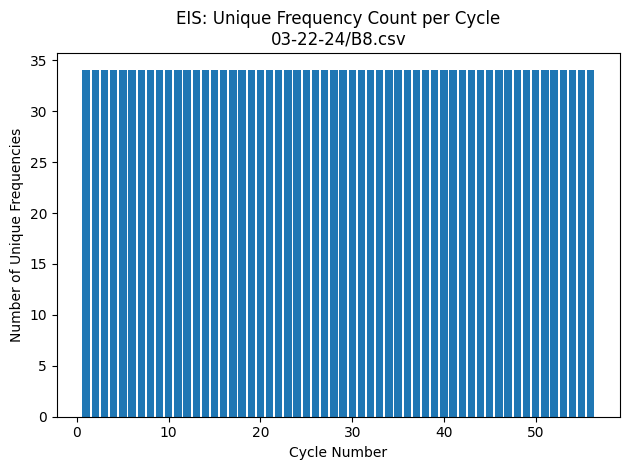

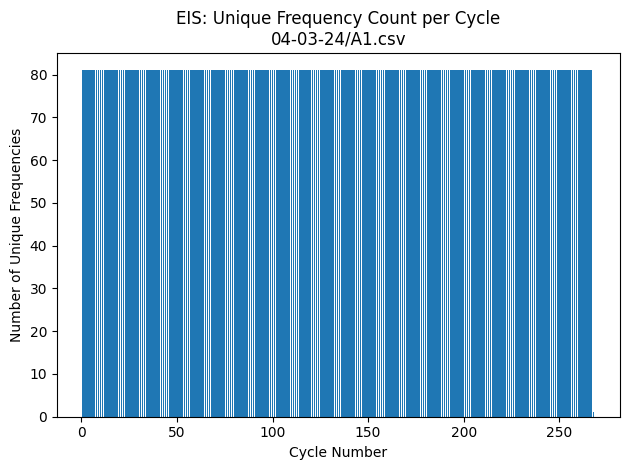

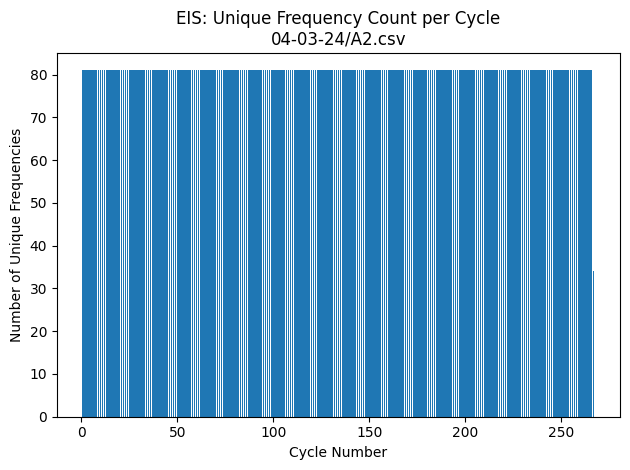

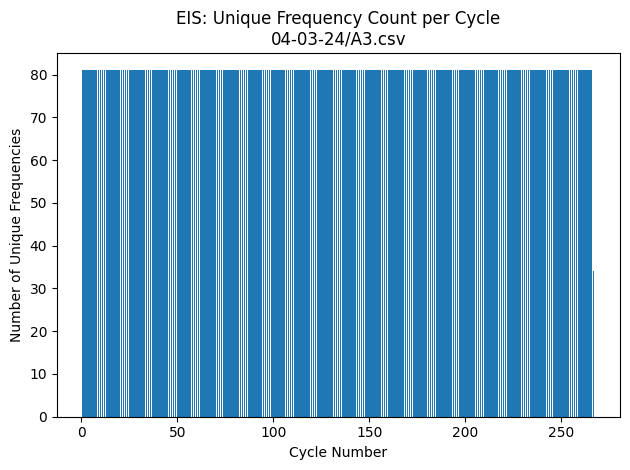

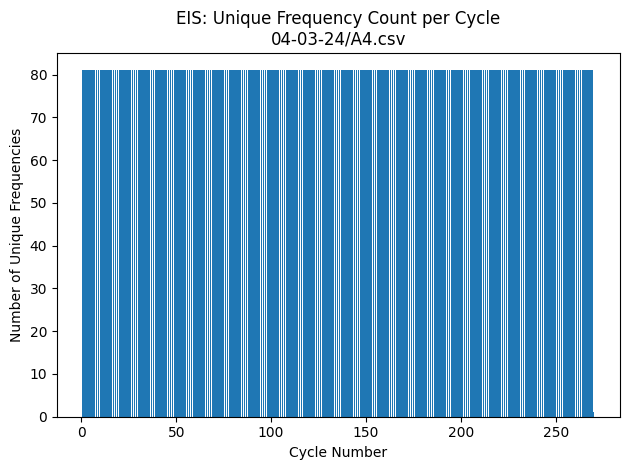

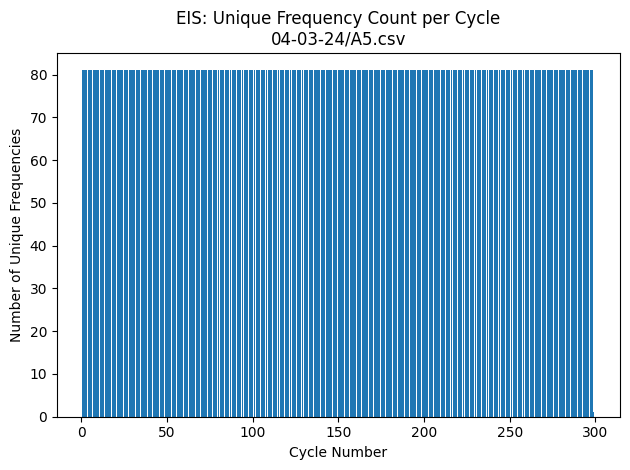

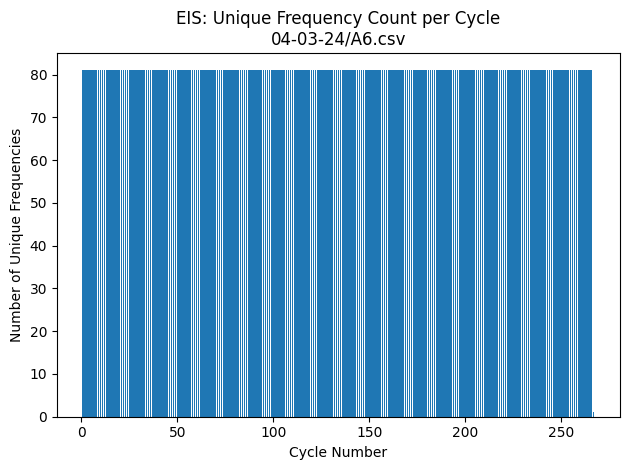

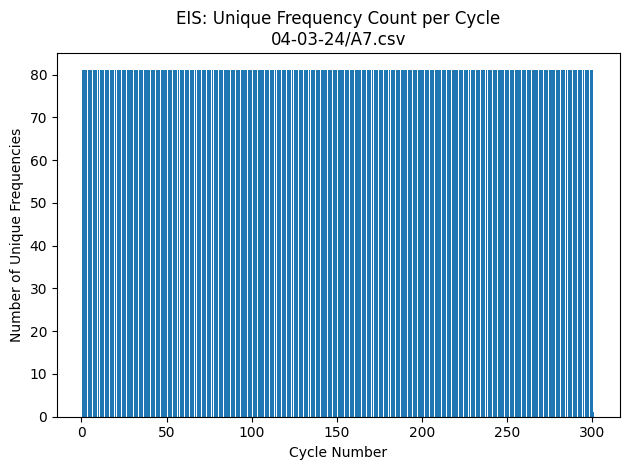

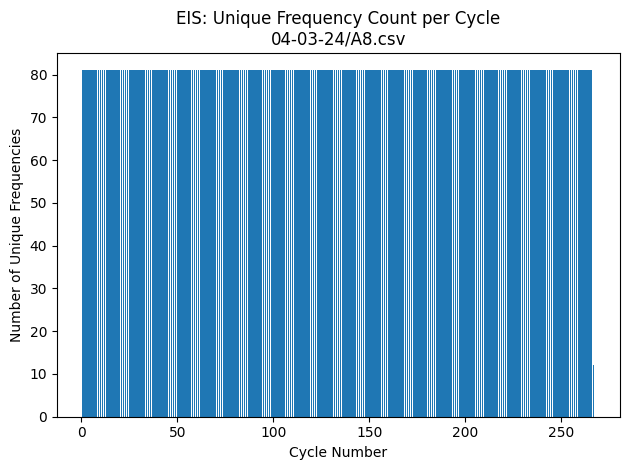

In [4]:
# Adjust this to point at the parent folder that contains your date-folders
data_root = "../data"

for folder in sorted(os.listdir(data_root)):
    folder_path = os.path.join(data_root, folder)
    if not os.path.isdir(folder_path):
        continue

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith('.csv'):
            continue

        # 1) Load
        df = data_pipeline.load_data(folder, filename)

        # 2) Compute unique-frequency count per cycle
        freq_counts = (
            df
            .groupby('cycle number')['freq/Hz']
            .nunique()
            .reset_index(name='unique_freq_count')
        )

        # 3) Plot
        plt.figure()
        plt.bar(freq_counts['cycle number'], freq_counts['unique_freq_count'])
        plt.xlabel('Cycle Number')
        plt.ylabel('Number of Unique Frequencies')
        plt.title(f'EIS: Unique Frequency Count per Cycle\n{folder}/{filename}')
        plt.tight_layout()
        plt.show()


## Preprocess for exploration

In [15]:
df = data_pipeline.load_data("04-03-24", "A4.csv")

df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]
unique_freqs = np.array(df['freq/Hz'].unique())
unique_freqs.sort()

print(unique_freqs)

[2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]


In [7]:
unique_counts_by_cycle = {}

# Get a sorted list of unique cycle numbers.
all_cycles = sorted(df['cycle number'].unique())

# Loop through each cycle, count, and print the unique frequencies.
for cycle in all_cycles:
    # Filter the DataFrame for the current cycle and count unique frequencies
    unique_count = len(np.unique(df[df['cycle number'] == cycle]['freq/Hz']))
    unique_counts_by_cycle[cycle] = unique_count
    print(f"Cycle {cycle} has {unique_count} unique frequency points.")


Cycle 1.0 has 69 unique frequency points.
Cycle 2.0 has 69 unique frequency points.
Cycle 3.0 has 69 unique frequency points.
Cycle 4.0 has 69 unique frequency points.
Cycle 5.0 has 69 unique frequency points.
Cycle 6.0 has 69 unique frequency points.
Cycle 7.0 has 69 unique frequency points.
Cycle 8.0 has 69 unique frequency points.
Cycle 9.0 has 69 unique frequency points.
Cycle 10.0 has 69 unique frequency points.
Cycle 11.0 has 69 unique frequency points.
Cycle 12.0 has 69 unique frequency points.
Cycle 13.0 has 69 unique frequency points.
Cycle 14.0 has 69 unique frequency points.
Cycle 15.0 has 69 unique frequency points.
Cycle 16.0 has 69 unique frequency points.
Cycle 17.0 has 69 unique frequency points.
Cycle 18.0 has 69 unique frequency points.
Cycle 19.0 has 69 unique frequency points.
Cycle 20.0 has 69 unique frequency points.
Cycle 21.0 has 69 unique frequency points.
Cycle 22.0 has 69 unique frequency points.
Cycle 23.0 has 69 unique frequency points.
Cycle 24.0 has 69 un

In [ ]:
# SOLUTION ANALYSIS: How frequency selection would help
print("=== FREQUENCY SELECTION IMPACT ANALYSIS ===")

print("Current problems identified:")
print(f"1. 533 feature pairs with >90% correlation (massive redundancy)")
print(f"2. Samples/feature ratio as low as 0.4 (severe overfitting)")
print(f"3. Wide capacity ranges requiring different physics models")

print(f"\nIf we select TOP 5-10 most important frequencies:")
print(f"Current: 140 features → Reduced: 5-10 features")

for result in results:
    reduced_features = 5  # Assume we select 5 key frequencies
    improved_ratio = result['n_samples'] / reduced_features
    print(f"{result['cycles']}: {result['samples_per_feature']:.1f} → {improved_ratio:.1f} samples/feature")

print(f"\nExpected benefits:")
print(f"✅ Eliminates 533 redundant feature pairs")
print(f"✅ Improves samples/feature ratio by ~28x")
print(f"✅ Focuses on physically meaningful frequencies")
print(f"✅ Reduces noise that causes sinusoidal residuals")
print(f"✅ Model complexity matches data availability")

print(f"\nPhysics-based frequency selection strategy:")
print(f"1. Target 1-10 Hz range (most sensitive to capacity loss)")
print(f"2. Include ~100 Hz (charge transfer resistance)")
print(f"3. Maybe 1-2 high frequencies for ohmic resistance")
print(f"4. Skip redundant adjacent frequencies")
print(f"5. Total: 3-5 key frequencies instead of 69")

print(f"\nThis directly addresses your sinusoidal residuals by:")
print(f"- Removing noisy/irrelevant frequencies")
print(f"- Focusing model on truly predictive signals")
print(f"- Reducing overfitting from high dimensionality")
print(f"- Creating more robust predictions across cycle ranges")# Let's analyze your actual data dimensions step by step
print("=== BASIC DIMENSIONALITY ANALYSIS ===")

# Load your typical dataset to check dimensions
X_train, X_test, y_train, y_test = data_pipeline.load_and_prepare_data(
    data_folder="04-03-24", 
    cycle_range=(1,160)  # Start with 160 cycles as you mentioned
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Samples per feature: {X_train.shape[0] / X_train.shape[1]:.1f}")

# Check for any NaN or infinite values that might cause issues
print(f"\n=== DATA QUALITY CHECK ===")
print(f"NaN values in X_train: {np.isnan(X_train).sum()}")
print(f"Infinite values in X_train: {np.isinf(X_train).sum()}")
print(f"NaN values in y_train: {np.isnan(y_train).sum()}")

# Check the range of your features
print(f"\n=== FEATURE RANGES ===")
print(f"X_train min: {np.nanmin(X_train):.6f}")
print(f"X_train max: {np.nanmax(X_train):.6f}")
print(f"X_train mean: {np.nanmean(X_train):.6f}")

# Since you have 140 features but 69 frequencies, let's understand the structure
print(f"\n=== FEATURE STRUCTURE ANALYSIS ===")
print(f"You mentioned 69 frequencies, but have {X_train.shape[1]} features")
print(f"This suggests: {X_train.shape[1] // 69:.0f} components per frequency (likely Real + Imaginary)")

# Check variance across features safely
feature_variances = np.var(X_train, axis=0)
print(f"Features with zero variance: {np.sum(feature_variances == 0)}")
print(f"Features with very low variance: {np.sum(feature_variances < 1e-10)}")

print(f"\n=== DIMENSIONALITY ASSESSMENT ===")
samples_per_feature = X_train.shape[0] / X_train.shape[1]

if samples_per_feature > 20:
    print("✅ GOOD: High samples-to-features ratio")
elif samples_per_feature > 10:
    print("⚠️ BORDERLINE: Adequate but could benefit from feature selection") 
else:
    print("❌ POOR: High risk of overfitting due to curse of dimensionality")
    
print(f"\nWith {X_train.shape[0]} samples and {X_train.shape[1]} features:")
print(f"Ratio = {samples_per_feature:.1f} samples per feature")

=== DIMENSIONALITY ANALYSIS ===
X_train: (160, 140), y_train: (160,)
X_test: (160, 140), y_test: (160,)
Capacity ranges - Train: 3610.0-4050.0, Test: 3450.0-4030.0
Training samples: 160
Test samples: 160
Number of features: 140
Samples per feature: 1.1
Feature pairs with correlation > 0.9: 517

=== FREQUENCY ANALYSIS ===
No column names - assuming features are frequency-ordered
Features with very low variance: 14

=== DIMENSIONALITY ASSESSMENT ===
❌ POOR: High risk of overfitting due to curse of dimensionality
X_train: (160, 140), y_train: (160,)
X_test: (160, 140), y_test: (160,)
Capacity ranges - Train: 3610.0-4050.0, Test: 3450.0-4030.0
Training samples: 160
Test samples: 160
Number of features: 140
Samples per feature: 1.1
Feature pairs with correlation > 0.9: 517

=== FREQUENCY ANALYSIS ===
No column names - assuming features are frequency-ordered
Features with very low variance: 14

=== DIMENSIONALITY ASSESSMENT ===
❌ POOR: High risk of overfitting due to curse of dimensionality


/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


LinAlgError: Array must not contain infs or NaNs

In [16]:
# Safe correlation analysis
print("=== CORRELATION ANALYSIS ===")

# Remove any features with zero variance before correlation analysis
non_zero_var_mask = np.var(X_train, axis=0) > 1e-10
X_train_clean = X_train[:, non_zero_var_mask]
print(f"Features after removing zero variance: {X_train_clean.shape[1]}")

if X_train_clean.shape[1] > 1:
    try:
        # Calculate correlation matrix safely
        correlation_matrix = np.corrcoef(X_train_clean.T)
        
        # Check for NaN in correlation matrix
        nan_correlations = np.isnan(correlation_matrix).sum()
        if nan_correlations > 0:
            print(f"Warning: {nan_correlations} NaN values in correlation matrix")
        else:
            # Count high correlations (excluding diagonal)
            high_corr_mask = (correlation_matrix > 0.9) & (correlation_matrix < 1.0)
            high_correlations = np.sum(high_corr_mask) // 2  # Divide by 2 since matrix is symmetric
            print(f"Feature pairs with correlation > 0.9: {high_correlations}")
            
            # Show distribution of correlations
            upper_triangle = correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]
            print(f"Correlation statistics:")
            print(f"  Mean correlation: {np.mean(upper_triangle):.3f}")
            print(f"  Max correlation: {np.max(upper_triangle):.3f}")
            print(f"  Correlations > 0.8: {np.sum(upper_triangle > 0.8)}")
            print(f"  Correlations > 0.9: {np.sum(upper_triangle > 0.9)}")
            
    except Exception as e:
        print(f"Error calculating correlations: {e}")
else:
    print("Not enough features for correlation analysis")

=== CORRELATION ANALYSIS ===
Features after removing zero variance: 139
Feature pairs with correlation > 0.9: 533
Correlation statistics:
  Mean correlation: 0.344
  Max correlation: 0.999
  Correlations > 0.8: 1194
  Correlations > 0.9: 518


In [17]:
# Analysis: Why performance degrades with more cycles
print("=== CYCLE RANGE IMPACT ANALYSIS ===")

# Test different cycle ranges to understand the pattern
cycle_ranges = [(1, 50), (1, 100), (1, 160), (1, 200), (1, 250)]
results = []

for start_cycle, end_cycle in cycle_ranges:
    print(f"\nTesting cycle range {start_cycle}-{end_cycle}:")
    
    try:
        X_tr, X_te, y_tr, y_te = data_pipeline.load_and_prepare_data(
            data_folder="04-03-24", 
            cycle_range=(start_cycle, end_cycle)
        )
        
        print(f"  Training samples: {X_tr.shape[0]}")
        print(f"  Capacity range: {y_tr.min():.0f} - {y_tr.max():.0f} mA.h")
        print(f"  Capacity span: {y_tr.max() - y_tr.min():.0f} mA.h")
        print(f"  Samples per feature: {X_tr.shape[0] / X_tr.shape[1]:.1f}")
        
        # Check if the capacity range is changing significantly
        capacity_std = np.std(y_tr)
        print(f"  Capacity std deviation: {capacity_std:.1f} mA.h")
        
        results.append({
            'cycles': f"{start_cycle}-{end_cycle}",
            'n_samples': X_tr.shape[0],
            'capacity_range': y_tr.max() - y_tr.min(),
            'capacity_std': capacity_std,
            'samples_per_feature': X_tr.shape[0] / X_tr.shape[1]
        })
        
    except Exception as e:
        print(f"  Error loading data: {e}")

print(f"\n=== SUMMARY TABLE ===")
print(f"{'Cycles':<10} {'Samples':<8} {'Cap Range':<10} {'Cap Std':<8} {'Samp/Feat':<10}")
print("-" * 55)
for result in results:
    print(f"{result['cycles']:<10} {result['n_samples']:<8} {result['capacity_range']:<10.0f} "
          f"{result['capacity_std']:<8.1f} {result['samples_per_feature']:<10.1f}")

print(f"\n=== INSIGHTS ===")
print("As you add more cycles:")
print("1. You get more training samples (good)")
print("2. BUT capacity range increases dramatically (bad)")
print("3. The model has to learn a much wider range of degradation states")
print("4. Early cycles (3800-4000 mA.h) vs late cycles (3000-3800 mA.h)")
print("5. Different physics govern different degradation stages")

print(f"\nThis explains your 'sinusoidal' residuals:")
print("- Model trained on wide range struggles with local patterns")
print("- Different degradation physics at different capacity levels")
print("- Need separate models or features for different degradation stages")

=== CYCLE RANGE IMPACT ANALYSIS ===

Testing cycle range 1-50:
X_train: (50, 140), y_train: (50,)
X_test: (50, 140), y_test: (50,)
Capacity ranges - Train: 3750.0-4050.0, Test: 3700.0-4030.0
  Training samples: 50
  Capacity range: 3750 - 4050 mA.h
  Capacity span: 300 mA.h
  Samples per feature: 0.4
  Capacity std deviation: 79.6 mA.h

Testing cycle range 1-100:
X_train: (100, 140), y_train: (100,)
X_test: (100, 140), y_test: (100,)
Capacity ranges - Train: 3670.0-4050.0, Test: 3580.0-4030.0
  Training samples: 100
  Capacity range: 3670 - 4050 mA.h
  Capacity span: 380 mA.h
  Samples per feature: 0.7
  Capacity std deviation: 91.7 mA.h

Testing cycle range 1-160:
X_train: (160, 140), y_train: (160,)
X_test: (160, 140), y_test: (160,)
Capacity ranges - Train: 3610.0-4050.0, Test: 3450.0-4030.0
  Training samples: 160
  Capacity range: 3610 - 4050 mA.h
  Capacity span: 440 mA.h
  Samples per feature: 1.1
  Capacity std deviation: 100.2 mA.h

Testing cycle range 1-200:
X_train: (200, 14

In [ ]:
plots.degradation(df)

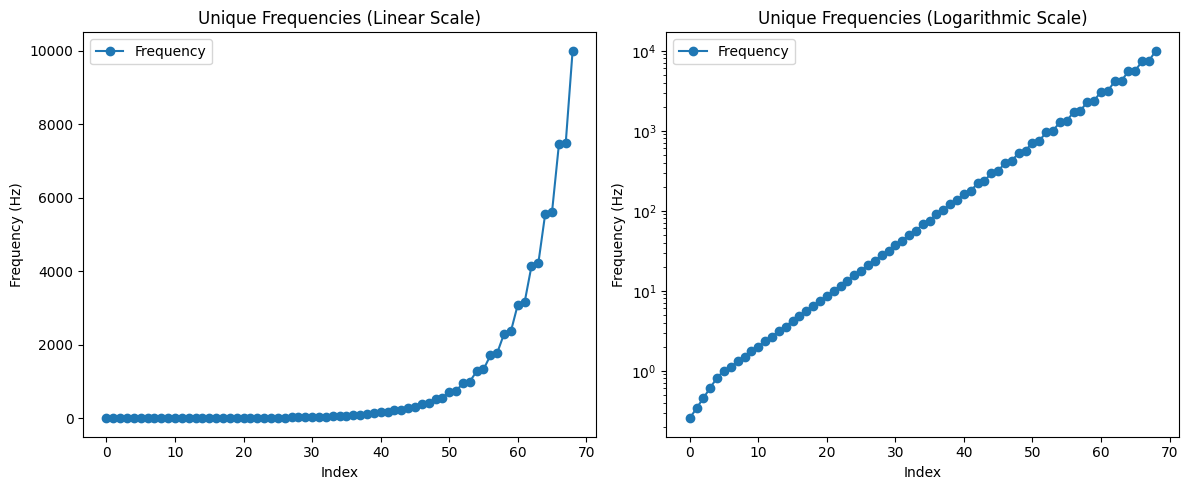

In [11]:
plots.unique_frequencies(unique_freqs)

## Exploring relevant frequencies

In [18]:
# Method 1: Correlation-based frequency selection
X_train, X_test, y_train, y_test = data_pipeline.load_and_prepare_data(
    data_folder="04-03-24", cycle_range=(1,160)
)

# Calculate correlation between each feature and target
feature_correlations = []
for i in range(X_train.shape[1]):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    feature_correlations.append(abs(corr))

feature_correlations = np.array(feature_correlations)

# Get top 10 most correlated features
top_indices = np.argsort(feature_correlations)[-10:]
print("Top 10 features by correlation:")
for i, idx in enumerate(top_indices[::-1]):
    print(f"{i+1}. Feature {idx}: correlation = {feature_correlations[idx]:.3f}")

# Method 2: XGBoost feature importance
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
feature_importance = xgb_model.feature_importances_

# Get top 10 by XGBoost importance
top_xgb_indices = np.argsort(feature_importance)[-10:]
print("\nTop 10 features by XGBoost importance:")
for i, idx in enumerate(top_xgb_indices[::-1]):
    print(f"{i+1}. Feature {idx}: importance = {feature_importance[idx]:.3f}")

# Compare the two methods
overlap = set(top_indices[-5:]) & set(top_xgb_indices[-5:])
print(f"\nOverlap in top 5 features: {len(overlap)} out of 5")
print(f"Overlapping features: {list(overlap)}")

# Select final set - features that rank high in both methods
combined_scores = (feature_correlations + feature_importance) / 2
final_top_indices = np.argsort(combined_scores)[-5:]

print(f"\nFinal top 5 features (combined ranking):")
for i, idx in enumerate(final_top_indices[::-1]):
    print(f"{i+1}. Feature {idx}: combined_score = {combined_scores[idx]:.3f}")

selected_features = final_top_indices

X_train: (160, 140), y_train: (160,)
X_test: (160, 140), y_test: (160,)
Capacity ranges - Train: 3610.0-4050.0, Test: 3450.0-4030.0
Top 10 features by correlation:
1. Feature 137: correlation = nan
2. Feature 139: correlation = 1.000
3. Feature 138: correlation = 0.998
4. Feature 90: correlation = 0.911
5. Feature 86: correlation = 0.907
6. Feature 88: correlation = 0.885
7. Feature 51: correlation = 0.883
8. Feature 82: correlation = 0.880
9. Feature 80: correlation = 0.877
10. Feature 56: correlation = 0.859


/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/nithin.jakrebet/Desktop/eis-ml/venv_py311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 features by XGBoost importance:
1. Feature 139: importance = 0.361
2. Feature 65: importance = 0.222
3. Feature 138: importance = 0.200
4. Feature 59: importance = 0.158
5. Feature 55: importance = 0.035
6. Feature 13: importance = 0.018
7. Feature 5: importance = 0.001
8. Feature 4: importance = 0.001
9. Feature 82: importance = 0.000
10. Feature 24: importance = 0.000

Overlap in top 5 features: 2 out of 5
Overlapping features: [np.int64(138), np.int64(139)]

Final top 5 features (combined ranking):
1. Feature 137: combined_score = nan
2. Feature 139: combined_score = 0.680
3. Feature 138: combined_score = 0.599
4. Feature 65: combined_score = 0.477
5. Feature 59: combined_score = 0.470


In [ ]:
# Test selected frequencies performance
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

print(f"Reduced from {X_train.shape[1]} to {X_train_selected.shape[1]} features")
print(f"New samples/feature ratio: {X_train_selected.shape[0] / X_train_selected.shape[1]:.1f}")

# Train model with selected features
models_selected = model_training.train_ensemble_model(X_train_selected, y_train)
y_pred_selected, y_pred_std_selected, _ = model_training.predict_ensemble(models_selected, X_test_selected)

# Compare performance
rmse_original, r2_original, _, mae_original = evaluate_model(y_test, y_pred_mean)
rmse_selected, r2_selected, _, mae_selected = evaluate_model(y_test, y_pred_selected)

print(f"\nPerformance comparison:")
print(f"{'Metric':<12} {'All Features':<12} {'Selected':<12} {'Change'}")
print("-" * 50)
print(f"{'RMSE':<12} {rmse_original:<12.1f} {rmse_selected:<12.1f} {((rmse_selected-rmse_original)/rmse_original*100):+.1f}%")
print(f"{'R²':<12} {r2_original:<12.3f} {r2_selected:<12.3f} {((r2_selected-r2_original)/r2_original*100):+.1f}%")
print(f"{'MAE':<12} {mae_original:<12.1f} {mae_selected:<12.1f} {((mae_selected-mae_original)/mae_original*100):+.1f}%")

# Check if residual patterns improved
residuals_selected = y_test - y_pred_selected
cycle_numbers = np.linspace(1, 160, len(y_test)).astype(int)
corr_selected = np.corrcoef(cycle_numbers, residuals_selected)[0,1]

print(f"\nTemporal correlation in residuals:")
print(f"All features: {corr_cycle:.4f}")
print(f"Selected features: {corr_selected:.4f}")

if abs(corr_selected) < abs(corr_cycle):
    print("✅ Improved: Less temporal correlation")
else:
    print("❌ No improvement in temporal patterns")

In [19]:
# Map feature indices to actual frequencies
print("=== MAPPING FEATURES TO FREQUENCIES ===")

# Your 69 frequencies from earlier analysis
frequencies = np.array([2.54e-01, 3.40e-01, 4.56e-01, 6.12e-01, 8.22e-01, 9.99e-01, 1.10e+00, 1.33e+00,
                       1.48e+00, 1.78e+00, 1.99e+00, 2.37e+00, 2.66e+00, 3.16e+00, 3.57e+00, 4.22e+00,
                       4.80e+00, 5.62e+00, 6.43e+00, 7.50e+00, 8.64e+00, 1.00e+01, 1.16e+01, 1.33e+01,
                       1.55e+01, 1.78e+01, 2.09e+01, 2.37e+01, 2.80e+01, 3.16e+01, 3.75e+01, 4.22e+01,
                       5.03e+01, 5.62e+01, 6.76e+01, 7.50e+01, 9.06e+01, 1.02e+02, 1.22e+02, 1.35e+02,
                       1.63e+02, 1.78e+02, 2.19e+02, 2.37e+02, 2.94e+02, 3.16e+02, 3.94e+02, 4.22e+02,
                       5.29e+02, 5.64e+02, 7.10e+02, 7.50e+02, 9.52e+02, 1.00e+03, 1.28e+03, 1.33e+03,
                       1.71e+03, 1.78e+03, 2.30e+03, 2.37e+03, 3.09e+03, 3.16e+03, 4.14e+03, 4.22e+03,
                       5.56e+03, 5.62e+03, 7.45e+03, 7.50e+03, 1.00e+04])

print(f"Total frequencies: {len(frequencies)}")
print(f"Total features: {X_train.shape[1]}")

# Decode the top features
print(f"\nDecoding top features:")
for i, feature_idx in enumerate([139, 138, 65, 59]):
    if feature_idx >= 138:
        print(f"Feature {feature_idx}: Action vector component {feature_idx - 137}")
    else:
        # Assuming features 0-68 are real parts, 69-137 are imaginary parts
        if feature_idx < 69:
            freq_idx = feature_idx
            component = "Real"
            freq_hz = frequencies[freq_idx]
        else:
            freq_idx = feature_idx - 69
            component = "Imaginary"  
            freq_hz = frequencies[freq_idx]
        
        print(f"Feature {feature_idx}: {component} part of {freq_hz:.2f} Hz")

# Show frequency ranges of selected features
print(f"\nSelected frequency analysis:")
selected_freqs = []
for feature_idx in [65, 59]:  # Only EIS features, excluding action vector
    if feature_idx < 69:
        freq_hz = frequencies[feature_idx]
    else:
        freq_hz = frequencies[feature_idx - 69]
    selected_freqs.append(freq_hz)
    
if selected_freqs:
    print(f"EIS frequency range: {min(selected_freqs):.1f} - {max(selected_freqs):.1f} Hz")
    print(f"This is in the: {'LOW' if max(selected_freqs) < 10 else 'MID' if max(selected_freqs) < 1000 else 'HIGH'} frequency range")
    
    # Compare to paper's recommendation (1-10 Hz)
    paper_range_count = sum(1 for f in selected_freqs if 1 <= f <= 10)
    print(f"Features in paper's recommended 1-10 Hz range: {paper_range_count}/{len(selected_freqs)}")
else:
    print("No EIS frequencies selected (only action vector)")

=== MAPPING FEATURES TO FREQUENCIES ===
Total frequencies: 69
Total features: 140

Decoding top features:
Feature 139: Action vector component 2
Feature 138: Action vector component 1
Feature 65: Real part of 5620.00 Hz
Feature 59: Real part of 2370.00 Hz

Selected frequency analysis:
EIS frequency range: 2370.0 - 5620.0 Hz
This is in the: HIGH frequency range
Features in paper's recommended 1-10 Hz range: 0/2
